In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!kaggle kernels output manvidhamija/transformer-model-ids -p /path/to/dest

Output file downloaded to /path/to/dest/best_transformer_model.pth
Output file downloaded to /path/to/dest/classification_report.csv
Output file downloaded to /path/to/dest/confusion_matrix.csv
Output file downloaded to /path/to/dest/normalized_confusion_matrix.csv
Output file downloaded to /path/to/dest/per_class_metrics.csv
Output file downloaded to /path/to/dest/test_predictions.csv
Output file downloaded to /path/to/dest/training_history.csv
Output file downloaded to /path/to/dest/window_manifest.csv
Output file downloaded to /path/to/dest/window_split_manifest.csv
Kernel log downloaded to /path/to/dest/transformer-model-ids.log 


In [3]:
!kaggle kernels output manvidhamija/flows-ids -p /path/to/dest

Output file downloaded to /path/to/dest/flow_tensors/flow_0000.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0001.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0002.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0003.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0004.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0005.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0006.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0007.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0008.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0009.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0010.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0011.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0012.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0013.pt
Output file downloaded to /path/to/dest/flow_tensors/flow_0014.pt
Output fil

In [4]:
!kaggle kernels output manvidhamija/ids-18 -p /path/to/dest

Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_1.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_10.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_11.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_12.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_13.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_14.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_15.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_16.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_17.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_18.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_19.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cleaned/clean_chunk_2.csv
Output file downloaded to /path/to/dest/CIC_IDS2018_Cl

In [5]:
!pip install shap

In [6]:
import torch
import shap
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [7]:
MODEL_CONFIG = {"input_dim": 43,"num_classes": 14,"window_size": 32,"stride": 8,"d_model": 128,"nhead": 8,"num_layers": 4,"dim_feedforward": 256,"dropout": 0.1,"batch_size": 256}

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.position_embedding = nn.Parameter(torch.randn(1, max_len, d_model))
    def forward(self, x):
        return x + self.position_embedding[:, :x.size(1)]
# Transformer Classifier
class TemporalTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        # Input Projection
        self.input_projection = nn.Linear(MODEL_CONFIG["input_dim"],MODEL_CONFIG["d_model"])
        # Positional Encoding
        self.position = PositionalEncoding(MODEL_CONFIG["window_size"],MODEL_CONFIG["d_model"])
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=MODEL_CONFIG["d_model"],nhead=MODEL_CONFIG["nhead"],dim_feedforward=MODEL_CONFIG["dim_feedforward"],dropout=MODEL_CONFIG["dropout"],activation="gelu",batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer,num_layers=MODEL_CONFIG["num_layers"])
        # Classification Head
        self.norm = nn.LayerNorm(MODEL_CONFIG["d_model"])
        self.dropout = nn.Dropout(MODEL_CONFIG["dropout"])
        self.classifier = nn.Linear(MODEL_CONFIG["d_model"],MODEL_CONFIG["num_classes"])
        # Weight Initialization
        self.apply(self._init_weights)
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    def forward(self, x):
        x = self.input_projection(x)
        x = self.position(x)
        x = self.encoder(x)
        # Mean Pooling
        x = x.mean(dim=1)
        x = self.norm(x)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TemporalTransformer().to(device)
model.load_state_dict(torch.load("/path/to/dest/best_transformer_model.pth", map_location=device))
model.eval()

TemporalTransformer(
  (input_projection): Linear(in_features=43, out_features=128, bias=True)
  (position): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=128, out_features=14, b

In [10]:
import pandas as pd
window_manifest = pd.read_csv("/path/to/dest/window_split_manifest.csv")

In [11]:
window_manifest = (window_manifest[window_manifest["Split"] != "Guard"].reset_index(drop=True))
# Dataset Class
class WindowDataset(Dataset):
    def __init__(self, manifest):
        self.manifest = (manifest.reset_index(drop=True).to_dict("records"))
        # Cache loaded tensors
        self.cache = {}
    def __len__(self):
        return len(self.manifest)
    def __getitem__(self, idx):
        row = self.manifest[idx]
        tensor_file = row["Tensor File"]
        if tensor_file not in self.cache:
            tensor_path = os.path.join(FLOW_DIR,tensor_file)
            self.cache[tensor_file] = torch.load(tensor_path,map_location="cpu")
        data = self.cache[tensor_file]
        start = int(row["Window Start"])
        end = int(row["Window End"])
        X = data["X"][start:end].float()
        y = torch.tensor(int(row["Label"]),dtype=torch.long)
        return X, y
# Split Manifests
train_manifest = (window_manifest[window_manifest["Split"] == "Train"].reset_index(drop=True))
val_manifest = (window_manifest[window_manifest["Split"] == "Validation"].reset_index(drop=True))
test_manifest = (window_manifest[window_manifest["Split"] == "Test"].reset_index(drop=True))
# Build Datasets
train_dataset = WindowDataset(train_manifest)
val_dataset = WindowDataset(val_manifest)
test_dataset = WindowDataset(test_manifest)

In [12]:
num_workers=2
FLOW_DIR = "/path/to/dest/flow_tensors"

In [13]:
# Train DataLoader
train_loader = DataLoader(train_dataset,batch_size=MODEL_CONFIG["batch_size"],shuffle=True,num_workers=2,pin_memory=torch.cuda.is_available(),persistent_workers=(num_workers > 0))
# Validation DataLoader
val_loader = DataLoader(val_dataset,batch_size=MODEL_CONFIG["batch_size"],shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available(),persistent_workers=(num_workers > 0))
# Test DataLoader
test_loader = DataLoader(test_dataset,batch_size=MODEL_CONFIG["batch_size"],shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available(),persistent_workers=(num_workers > 0))

In [14]:
X_train, y_train = next(iter(train_loader))
X_test, y_test = next(iter(test_loader))

print("Train batch:", X_train.shape)
print("Train labels:", y_train.shape)

print("Test batch:", X_test.shape)
print("Test labels:", y_test.shape)

Train batch: torch.Size([256, 32, 43])
Train labels: torch.Size([256])
Test batch: torch.Size([256, 32, 43])
Test labels: torch.Size([256])


In [15]:
background = X_train[:50].to(device)      # Background/reference samples
samples = X_test[:20].to(device)          # Samples to explain
print("Background:", background.shape)
print("Samples:", samples.shape)

Background: torch.Size([50, 32, 43])
Samples: torch.Size([20, 32, 43])


In [16]:
import shap
model.eval()
explainer = shap.GradientExplainer(model, background)

In [17]:
shap_values = explainer.shap_values(samples)
print(type(shap_values))
if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    print("Shape of first class:", shap_values[0].shape)
else:
    print(shap_values.shape)

<class 'numpy.ndarray'>
(20, 32, 43, 14)


In [18]:
import numpy as np
import matplotlib.pyplot as plt
# Mean absolute SHAP value
feature_importance = np.mean(np.abs(shap_values), axis=(0, 1, 3))
print(feature_importance.shape)   # (43,)

(43,)


In [19]:
BASE_FEATURES = ["Init Fwd Win Byts","Fwd Seg Size Min","Fwd Header Len","Dst Port","Flow Duration","Flow IAT Max","Fwd Pkts/s","Flow Pkts/s","Flow IAT Mean","Init Bwd Win Byts","Fwd IAT Tot","Bwd Pkts/s","Tot Fwd Pkts","Flow IAT Min","TotLen Fwd Pkts","Fwd IAT Max","Fwd IAT Mean","Fwd Act Data Pkts","Fwd IAT Min","Flow IAT Std","Fwd Pkt Len Std","Bwd IAT Min","Bwd Header Len","Bwd IAT Mean","Pkt Len Max","Bwd Pkt Len Max","Fwd Pkt Len Max","Bwd Pkt Len Std","Fwd IAT Std","Bwd IAT Max","Pkt Len Std","Pkt Len Var","Fwd Pkt Len Mean","Tot Bwd Pkts","Bwd Pkt Len Mean"]
HTRE_FEATURES = ["TRE_TimeGap","TRE_LogFlowDurationChange","TRE_LogFlowPktsChange","TRE_LogFlowBytsChange","TRE_RollMeanFlowDuration","TRE_RollStdFlowDuration","TRE_RollMeanFlowPkts","TRE_RollStdFlowPkts"]
FEATURE_COLUMNS = BASE_FEATURES + HTRE_FEATURES
print("Total Features :", len(FEATURE_COLUMNS))

Total Features : 43


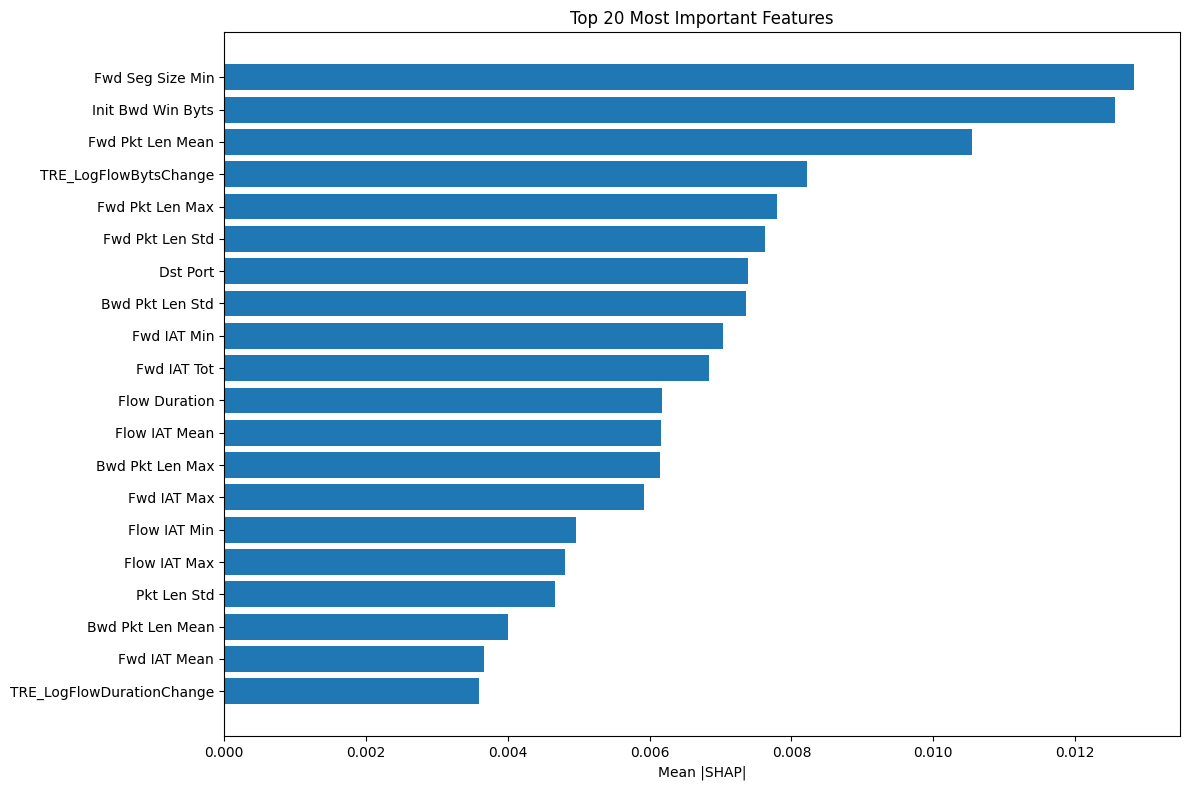

In [20]:
importance_df = (pd.DataFrame({"Feature": FEATURE_COLUMNS,"Importance": feature_importance}).sort_values("Importance", ascending=False))
plt.figure(figsize=(12,8))
plt.barh(importance_df["Feature"][:20][::-1],importance_df["Importance"][:20][::-1])
plt.xlabel("Mean |SHAP|")
plt.title("Top 20 Most Important Features")
plt.tight_layout()
plt.show()


In [21]:
importance_df["Feature Type"] = importance_df["Feature"].apply(lambda x: "HTRE" if x.startswith("TRE_") else "Base")
summary = (importance_df.groupby("Feature Type")["Importance"].agg(["count", "mean", "sum"]))
print(summary)

              count      mean       sum
Feature Type                           
Base             35  0.004091  0.143200
HTRE              8  0.002539  0.020316


In [22]:
htre_df = importance_df[importance_df["Feature"].str.startswith("TRE_")].sort_values("Importance", ascending=False)
print(htre_df)

                      Feature    Importance Feature Type
38      TRE_LogFlowBytsChange  8.220446e-03         HTRE
36  TRE_LogFlowDurationChange  3.588827e-03         HTRE
37      TRE_LogFlowPktsChange  3.018104e-03         HTRE
40    TRE_RollStdFlowDuration  2.393415e-03         HTRE
39   TRE_RollMeanFlowDuration  1.319628e-03         HTRE
42        TRE_RollStdFlowPkts  9.781977e-04         HTRE
41       TRE_RollMeanFlowPkts  7.968837e-04         HTRE
35                TRE_TimeGap  8.215773e-10         HTRE


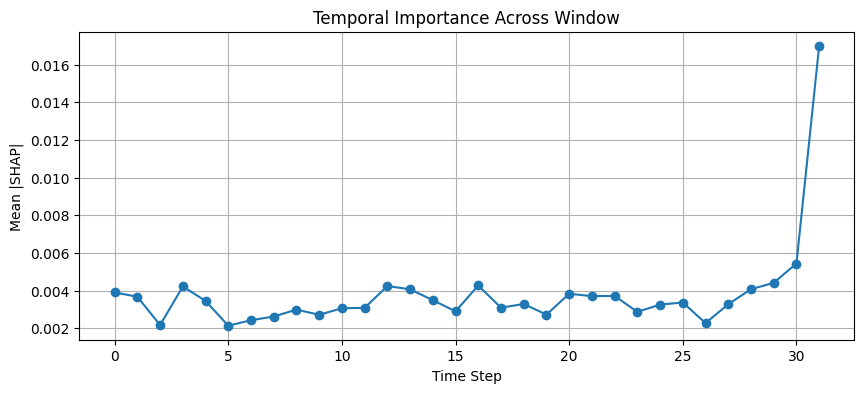

In [23]:
temporal_importance = np.mean(np.abs(shap_values)axis=(0,2,3))
plt.figure(figsize=(10,4))
plt.plot(range(32), temporal_importance, marker='o')
plt.xlabel("Time Step")
plt.ylabel("Mean |SHAP|")
plt.title("Temporal Importance Across Window")
plt.grid(True)
plt.show()

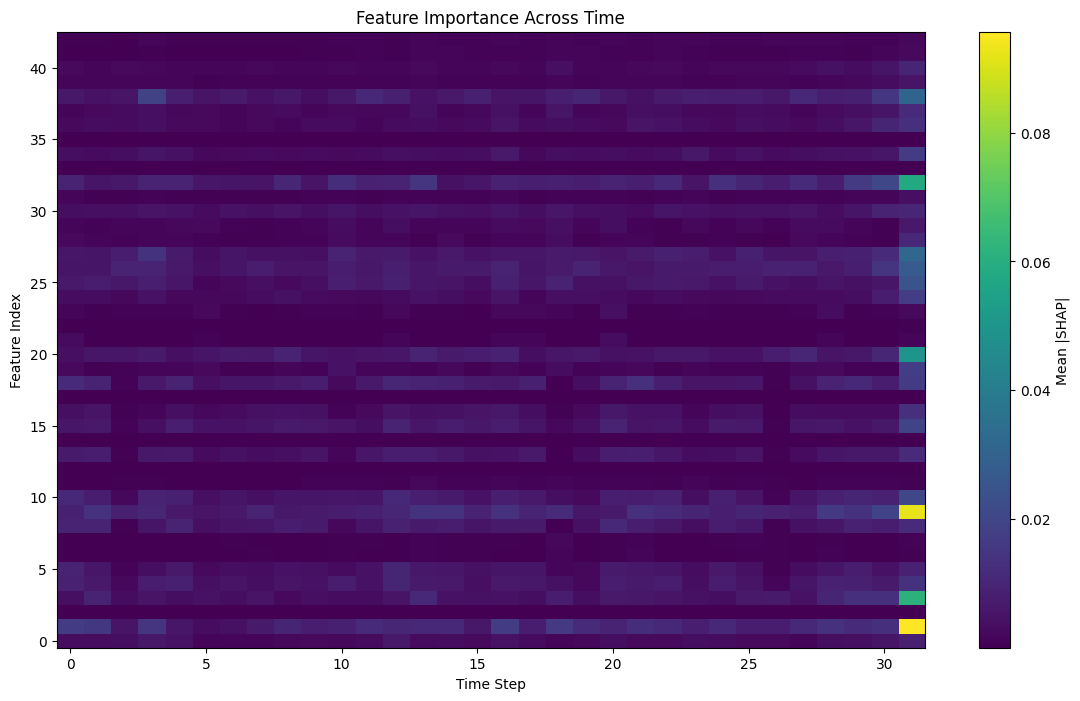

In [24]:
heatmap = np.mean(np.abs(shap_values),axis=(0,3))
plt.figure(figsize=(14,8))
plt.imshow(heatmap.T, aspect='auto', origin='lower')
plt.colorbar(label="Mean |SHAP|")
plt.xlabel("Time Step")
plt.ylabel("Feature Index")
plt.title("Feature Importance Across Time")
plt.show()

In [25]:
CLASS_NAMES = ["Benign","Brute Force -Web","Brute Force -XSS","DDOS attack-HOIC","DDOS attack-LOIC-UDP","DDoS attacks-LOIC-HTTP","DoS attacks-GoldenEye","DoS attacks-Hulk","DoS attacks-SlowHTTPTest","DoS attacks-Slowloris","FTP-BruteForce","Infilteration","SQL Injection","SSH-Bruteforce"]

In [26]:
import numpy as np
import pandas as pd
class_feature_importance = {}
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_shap = shap_values[:, :, :, class_idx]
    importance = np.mean(np.abs(class_shap), axis=(0, 1))
    class_feature_importance[class_name] = importance
class_feature_importance = pd.DataFrame(class_feature_importance,index=FEATURE_COLUMNS)
class_feature_importance.head()

,Benign,Brute Force -Web,Brute Force -XSS,DDOS attack-HOIC,DDOS attack-LOIC-UDP,DDoS attacks-LOIC-HTTP,DoS attacks-GoldenEye,DoS attacks-Hulk,DoS attacks-SlowHTTPTest,DoS attacks-Slowloris,FTP-BruteForce,Infilteration,SQL Injection,SSH-Bruteforce
Init Fwd Win Byts,0.001877,0.002786,0.003885,0.003886,0.002867,0.002983,0.003588,0.002944,0.003012,0.002729,0.001584,0.006740,0.002615,0.004227
Fwd Seg Size Min,0.007510,0.009949,0.013346,0.008659,0.015523,0.017986,0.015781,0.011283,0.010329,0.006595,0.006426,0.031361,0.009508,0.015447
Fwd Header Len,0.000021,0.000021,0.000029,0.000016,0.000051,0.000044,0.000035,0.000024,0.000036,0.000015,0.000017,0.000051,0.000018,0.000037
Dst Port,0.006080,0.004889,0.007000,0.004681,0.008506,0.014774,0.008348,0.005526,0.005707,0.003582,0.005272,0.016619,0.004975,0.007377
Flow Duration,0.002563,0.003683,0.005493,0.003714,0.008867,0.007933,0.011336,0.007760,0.003374,0.003140,0.001313,0.019336,0.004402,0.003584


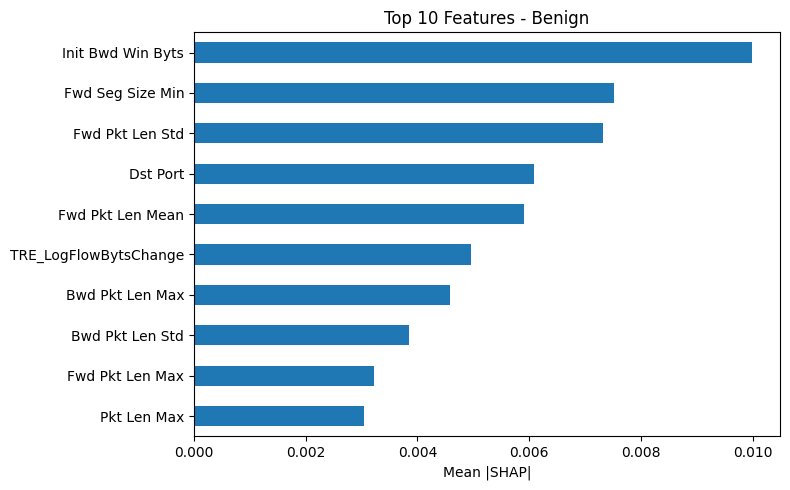

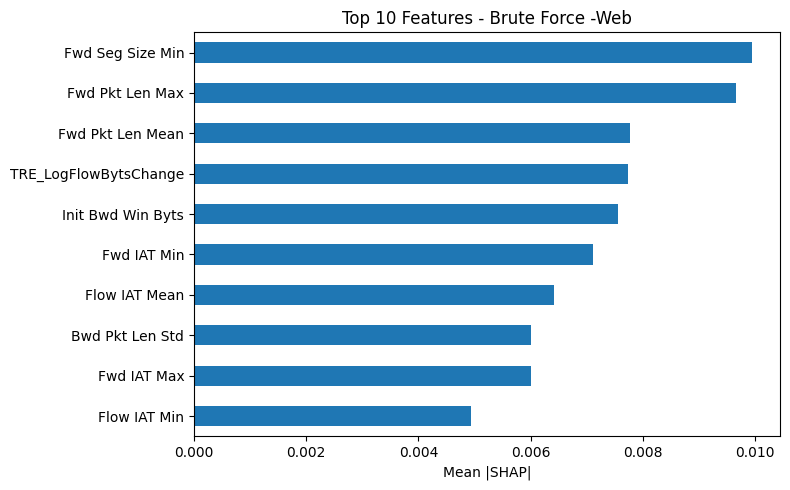

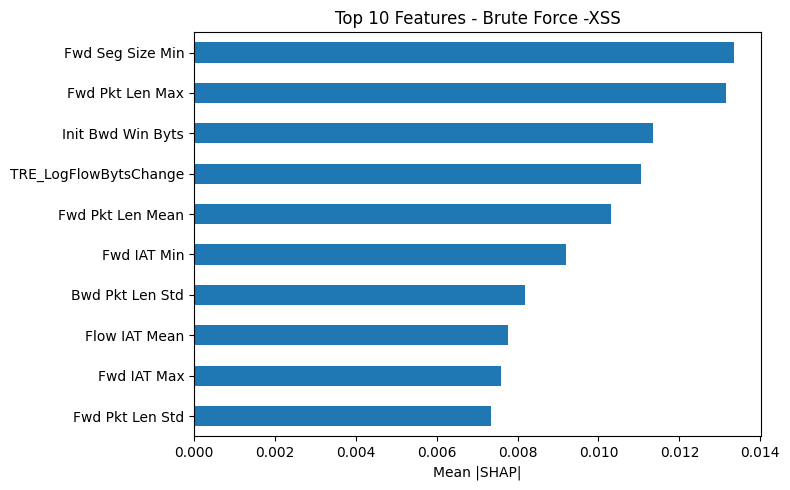

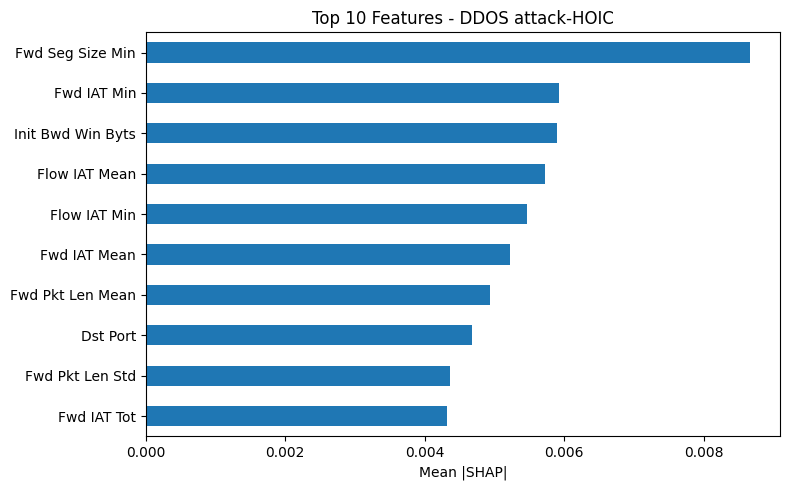

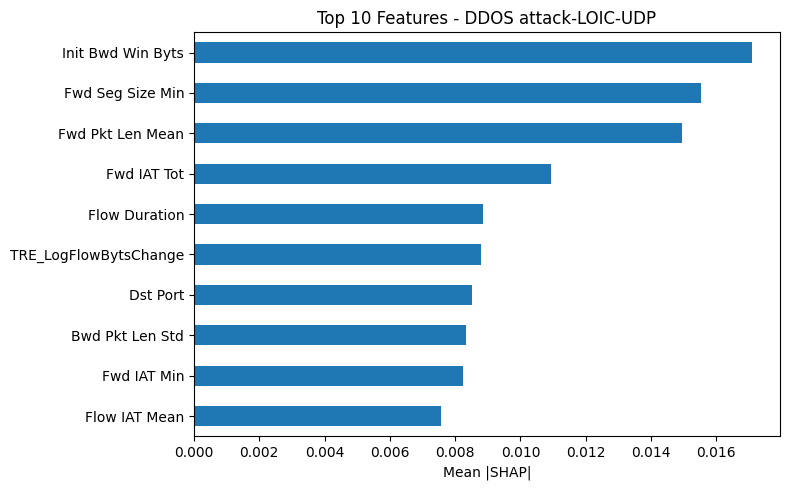

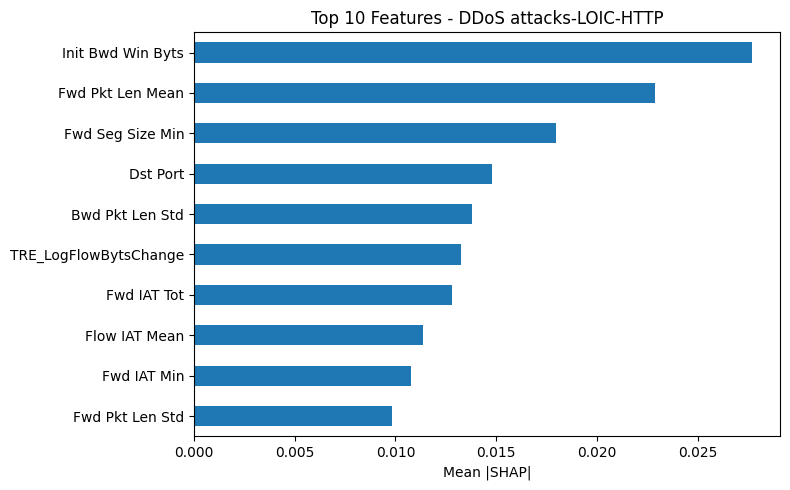

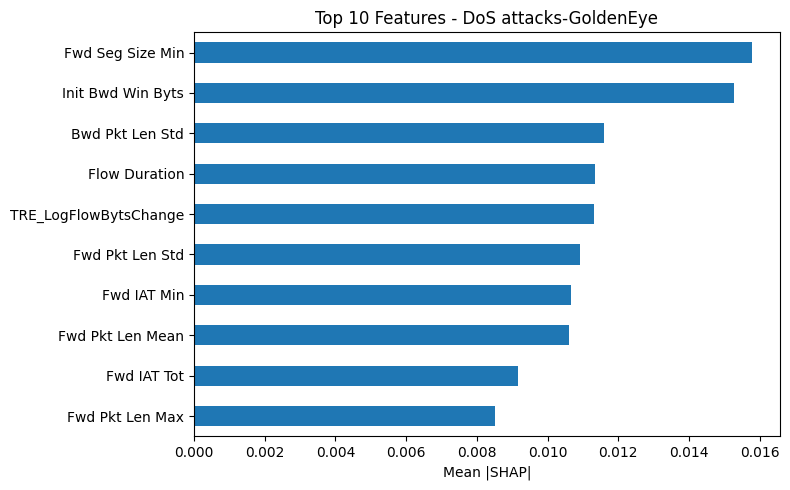

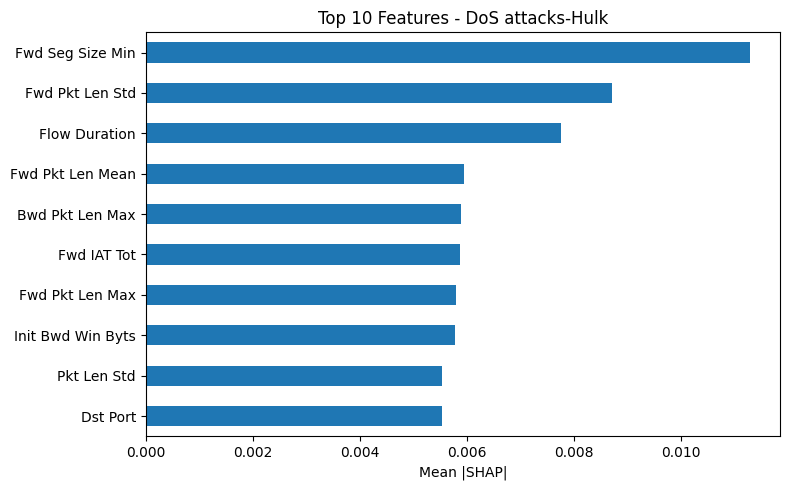

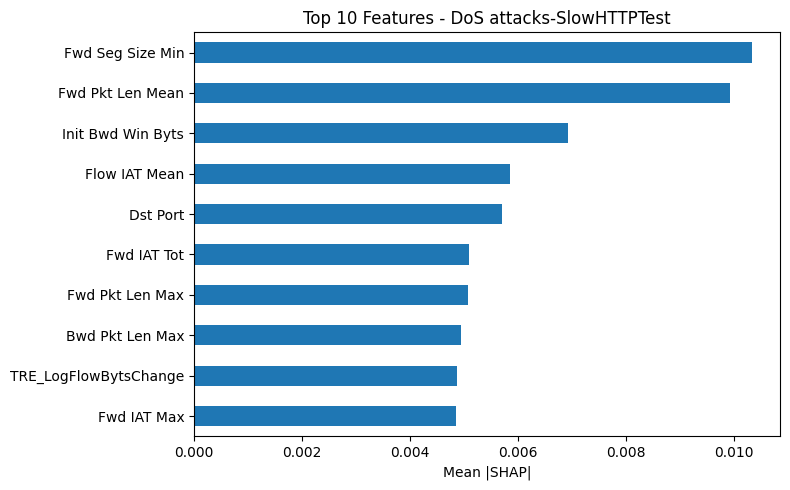

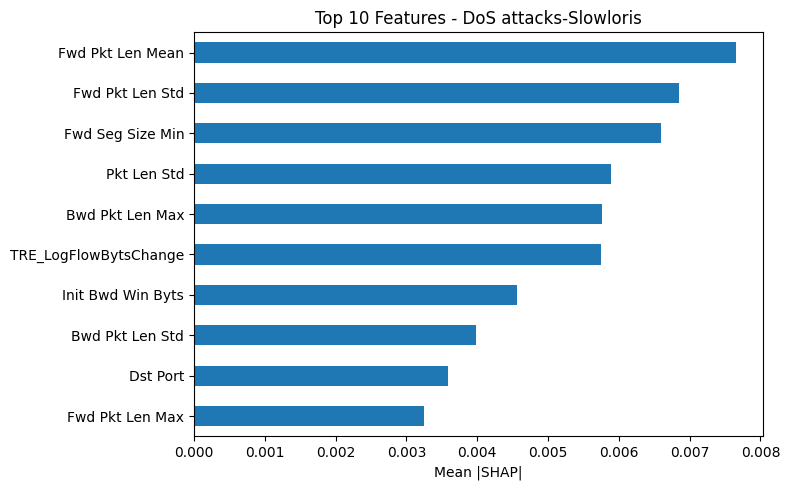

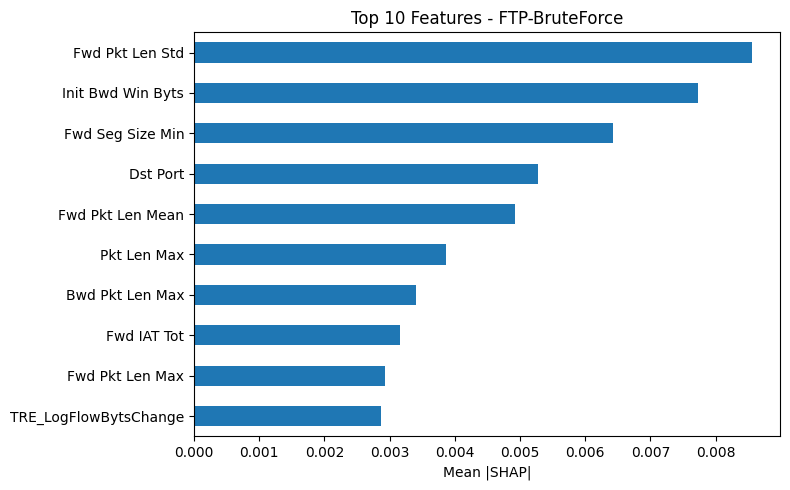

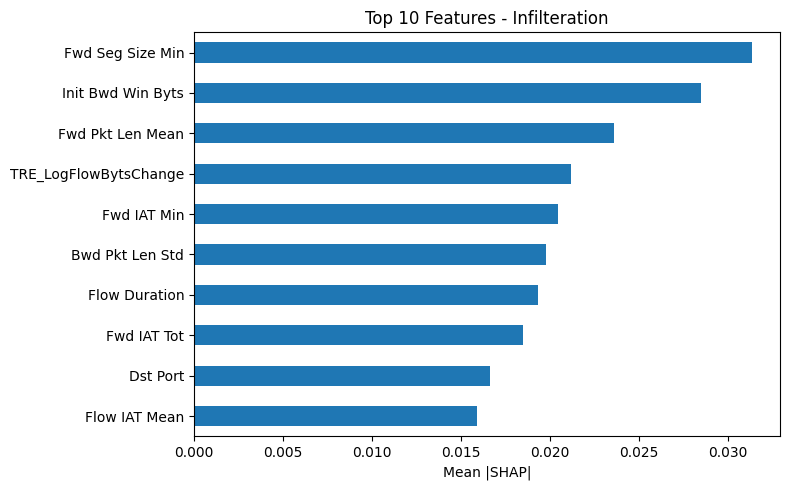

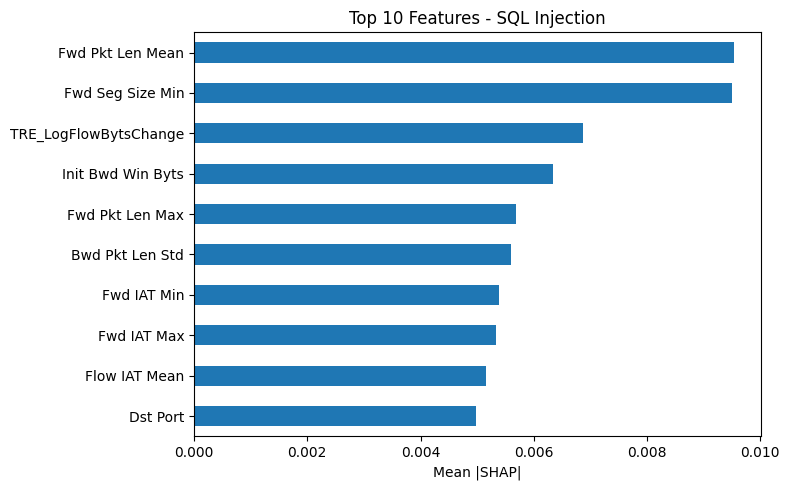

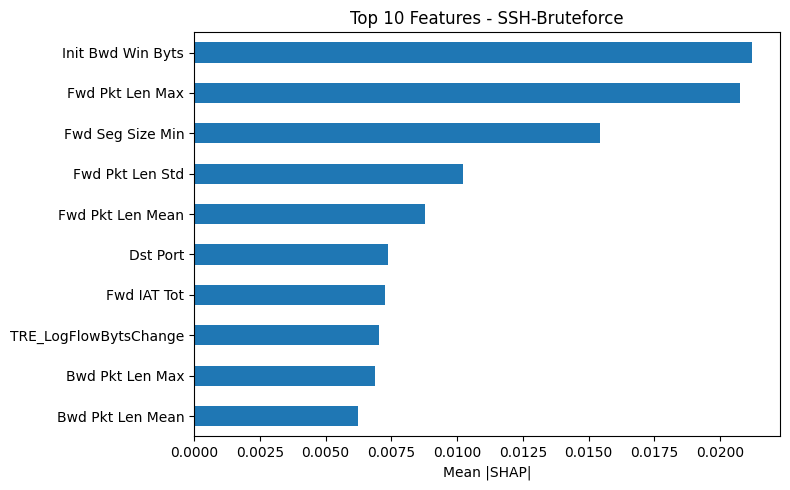

In [27]:
import matplotlib.pyplot as plt

for class_name in CLASS_NAMES:
    top = (class_feature_importance[class_name].sort_values(ascending=False).head(10))
    plt.figure(figsize=(8,5))
    top[::-1].plot(kind="barh")
    plt.title(f"Top 10 Features - {class_name}")
    plt.xlabel("Mean |SHAP|")
    plt.tight_layout()
    plt.show()

In [28]:
class_feature_importance.to_csv("classwise_shap_importance.csv")

In [29]:
importance_df.to_csv("global_shap_importance.csv", index=False)
class_feature_importance.to_csv("classwise_shap_importance.csv")

In [30]:
plt.savefig("global_feature_importance.png", dpi=300, bbox_inches="tight")
plt.savefig("temporal_importance.png", dpi=300, bbox_inches="tight")
plt.savefig("feature_time_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{class_name}_shap.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

**Threat Intelligence**

In [31]:
ATTACK_KNOWLEDGE = {}
ATTACK_KNOWLEDGE["SSH-Bruteforce"] = {"category": "Credential Access","description": ("Repeated SSH login attempts intended to obtain valid ""authentication credentials through brute-force authentication."),"mitre": {"technique_id": "T1110","technique": "Brute Force","tactic": "Credential Access"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1110/"}}
ATTACK_KNOWLEDGE["FTP-BruteForce"] = {"category": "Credential Access","description": ("Repeated FTP authentication attempts intended to compromise " "valid user credentials."),"mitre": {"technique_id": "T1110","technique": "Brute Force","tactic": "Credential Access"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1110/"}}
ATTACK_KNOWLEDGE["Brute Force -Web"] = {"category": "Credential Access","description": ("Repeated authentication attempts against a web application " "login interface to obtain valid credentials."),"mitre": {"technique_id": "T1110","technique": "Brute Force","tactic": "Credential Access"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1110/"}}
ATTACK_KNOWLEDGE["SQL Injection"] = {"category": "Web Application Attack","description": ("An attack that injects malicious SQL statements into application " "inputs to manipulate backend databases, retrieve unauthorized " "information, or modify stored data."),"mitre": {"technique_id": "T1190","technique": "Exploit Public-Facing Application","tactic": "Initial Access"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1190/","owasp": "https://owasp.org/www-community/attacks/SQL_Injection"}}
ATTACK_KNOWLEDGE["Brute Force -XSS"] = {"category": "Web Application Attack","description": ("An attack targeting publicly accessible web applications through " "malicious input injection. Within the CSE-CIC-IDS2018 dataset, " "this class represents web application exploitation behavior."),"mitre": {"technique_id": "T1190","technique": "Exploit Public-Facing Application","tactic": "Initial Access"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1190/","owasp": "https://owasp.org/www-community/attacks/xss/"}}
ATTACK_KNOWLEDGE["DoS attacks-Hulk"] = {"category": "Denial-of-Service","description": ("A high-volume HTTP flood attack designed to exhaust server " "resources by generating excessive HTTP requests."),"mitre": {"technique_id": "T1498","technique": "Network Denial of Service","tactic": "Impact"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1498/"}}
ATTACK_KNOWLEDGE["DoS attacks-GoldenEye"] = {"category": "Denial-of-Service","description": ("A HTTP-based denial-of-service attack that overwhelms web " "servers by generating large numbers of application requests."),"mitre": {"technique_id": "T1498","technique": "Network Denial of Service","tactic": "Impact"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1498/"}}
ATTACK_KNOWLEDGE["DoS attacks-Slowloris"] = {"category": "Denial-of-Service","description": ("A low-bandwidth denial-of-service attack that keeps numerous " "HTTP connections open using incomplete requests."),"mitre": {"technique_id": "T1498","technique": "Network Denial of Service","tactic": "Impact"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1498/"}}
ATTACK_KNOWLEDGE["DoS attacks-SlowHTTPTest"] = {"category": "Denial-of-Service","description": ("A slow HTTP attack that consumes server resources by sending " "HTTP requests or responses at extremely low rates."),"mitre": {"technique_id": "T1498","technique": "Network Denial of Service","tactic": "Impact"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1498/"}}
ATTACK_KNOWLEDGE["DDOS attack-HOIC"] = {"category": "Distributed Denial-of-Service","description": ("A distributed HTTP flood attack generated using the High Orbit " "Ion Cannon (HOIC) tool to overwhelm network services."),"mitre": {"technique_id": "T1498","technique": "Network Denial of Service","tactic": "Impact"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1498/"}}
ATTACK_KNOWLEDGE["DDoS attacks-LOIC-HTTP"] = {"category": "Distributed Denial-of-Service","description": ("A distributed HTTP flooding attack generated using the Low Orbit " "Ion Cannon (LOIC) tool."),"mitre": {"technique_id": "T1498","technique": "Network Denial of Service","tactic": "Impact"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1498/"}}
ATTACK_KNOWLEDGE["DDOS attack-LOIC-UDP"] = {"category": "Distributed Denial-of-Service","description": ("A distributed UDP flooding attack generated using the Low Orbit " "Ion Cannon (LOIC) tool."),"mitre": {"technique_id": "T1498","technique": "Network Denial of Service","tactic": "Impact"},"references": {"dataset": "CSE-CIC-IDS2018","mitre": "https://attack.mitre.org/techniques/T1498/"}}
ATTACK_KNOWLEDGE["Infilteration"] = {"category": "Network Intrusion","description": ("Unauthorized activity in which an attacker gains access to a " "target network and establishes a presence within the environment. " "The CSE-CIC-IDS2018 dataset labels this traffic as 'Infilteration', " "but does not associate it with a single standardized ATT&CK technique."),"mitre": {"technique_id": None,"technique": None,"tactic": None},"references": {"dataset": "CSE-CIC-IDS2018"}}
ATTACK_KNOWLEDGE["Benign"] = {"category": "Normal Traffic","description": ("Legitimate network traffic representing normal user and system " "activities without malicious intent."),"mitre": {"technique_id": None,"technique": None,"tactic": None},"references": {"dataset": "CSE-CIC-IDS2018"}}

In [32]:
print(f"Total attack classes: {len(ATTACK_KNOWLEDGE)}")
print("\nAvailable Classes:")
for attack in ATTACK_KNOWLEDGE:
    print(f"• {attack}")

Total attack classes: 14

Available Classes:
• SSH-Bruteforce
• FTP-BruteForce
• Brute Force -Web
• SQL Injection
• Brute Force -XSS
• DoS attacks-Hulk
• DoS attacks-GoldenEye
• DoS attacks-Slowloris
• DoS attacks-SlowHTTPTest
• DDOS attack-HOIC
• DDoS attacks-LOIC-HTTP
• DDOS attack-LOIC-UDP
• Infilteration
• Benign


In [33]:
SEVERITY_WEIGHTS = {"Low": 25 , "Medium": 50 , "High": 75 , "Critical": 100}

In [34]:
CONFIDENCE_LEVELS = {"Very High": 90,"High": 75,"Moderate": 60,"Low": 0}

In [35]:
SEVERITY_SCORES = {"Low": 25, "Medium": 50,"High": 75,"Critical": 100}
PRIORITY_LEVELS = {"Low": "P4","Medium": "P3","High": "P2","Critical": "P1"}

In [36]:
BASE_SEVERITY = {"Benign": "Low","SSH-Bruteforce": "Medium","FTP-BruteForce": "Medium","Brute Force -Web": "Medium","Brute Force -XSS": "High","SQL Injection": "Critical","DoS attacks-Hulk": "High","DoS attacks-GoldenEye": "High","DoS attacks-Slowloris": "Medium","DoS attacks-SlowHTTPTest": "Medium","DDOS attack-HOIC": "Critical","DDOS attack-LOIC-UDP": "Critical","DDoS attacks-LOIC-HTTP": "Critical","Infilteration": "Critical"}
SEVERITY_ORDER = ["Low", "Medium", "High", "Critical"]
def determine_severity(attack_class, confidence):
    """
    Determine adaptive threat severity using the Transformer prediction
    and confidence score.

    Parameters
    ----------
    attack_class : str
        Predicted attack class.
    confidence : float
        Prediction confidence (0–100).

    Returns
    -------
    str
        Adaptive severity level.
    """
    base = BASE_SEVERITY.get(attack_class, "Medium")
    level = SEVERITY_ORDER.index(base)
    if confidence < 60:
        level = max(0, level - 2)
    elif confidence < 80:
        level = max(0, level - 1)
    elif confidence >= 98:
        level = min(3, level + 1)
    return SEVERITY_ORDER[level]

In [38]:
def calculate_risk_score(severity, confidence):
    """
    Calculate an adaptive risk score.
    Parameters
    ----------
    severity : str
        Severity level returned by determine_severity().

    confidence : float
        Transformer confidence (0-100).
    Returns
    -------
    float
        Risk score (0-100).
    """
    severity_score = SEVERITY_SCORES[severity]
    risk_score = (severity_score * confidence) / 100
    return round(risk_score, 2)

In [39]:
def classify_risk(risk_score):
    """
    Convert numerical risk score into a qualitative risk level.
    """
    if risk_score >= 85:
        return "Critical"
    elif risk_score >= 65:
        return "High"
    elif risk_score >= 40:
        return "Medium"
    else:
        return "Low"

In [40]:
def assess_threat(attack_class, confidence):
    """
    Perform an adaptive threat assessment.
    Parameters
    ----------
    attack_class : str
        Predicted attack class.
    confidence : float
        Transformer prediction confidence (0-100).
    Returns
    -------
    dict
        Complete threat assessment.
    """
    severity = determine_severity(attack_class, confidence)
    risk_score = calculate_risk_score(severity,confidence)
    risk_level = classify_risk(risk_score)
    priority = PRIORITY_LEVELS[risk_level]
    return {"attack": attack_class,"confidence": round(confidence, 2),"severity": severity,"risk_score": risk_score,"risk_level": risk_level,"priority": priority}

In [41]:
example = assess_threat(attack_class="SQL Injection",confidence=96.8)
for key, value in example.items():
    print(f"{key:12}: {value}")

attack      : SQL Injection
confidence  : 96.8
severity    : Critical
risk_score  : 96.8
risk_level  : Critical
priority    : P1


In [42]:
RESPONSE_ACTIONS = {"Credential Access": ["Block suspicious authentication attempts.","Enable multi-factor authentication (MFA).","Reset compromised credentials.","Review authentication logs."],
                    "Web Application Attack": ["Inspect web server logs.","Validate application input filtering.","Apply security patches.","Deploy or update Web Application Firewall (WAF) rules."],
                    "Denial-of-Service": ["Rate-limit incoming traffic.","Filter malicious IP addresses.","Enable DDoS mitigation services.","Monitor server resource utilization."],
                    "Distributed Denial-of-Service": ["Activate DDoS protection.","Redirect traffic using CDN or scrubbing services.","Filter malicious traffic upstream.","Coordinate with the network provider."],
                    "Network Intrusion": ["Isolate affected hosts.","Inspect lateral movement.","Review firewall activity.","Perform forensic analysis."],
                    "Normal Traffic": ["No action required.","Continue routine monitoring."]}

In [43]:
def generate_recommendations(assessment):
    attack = assessment["attack"]
    category = ATTACK_KNOWLEDGE[attack]["category"]
    return RESPONSE_ACTIONS.get(category,["No recommendation available."])

In [44]:
assessment = assess_threat("SQL Injection",96.8)
recommendations = generate_recommendations(assessment)
print("Recommendations:\n")
for i, action in enumerate(recommendations, start=1):
    print(f"{i}. {action}")

Recommendations:

1. Inspect web server logs.
2. Validate application input filtering.
3. Apply security patches.
4. Deploy or update Web Application Firewall (WAF) rules.


report

In [57]:
def summarize_shap_features(shap_values, feature_names, top_k=5):
    """
    Extract the top contributing features based on absolute SHAP values.
    """
    importance = np.abs(shap_values)
    top_indices = np.argsort(importance)[::-1][:top_k]
    return [feature_names[i] for i in top_indices]

In [67]:
import pandas as pd

class_shap = pd.read_csv("classwise_shap_importance.csv")
class_shap.rename(columns={"Unnamed: 0": "Feature"}, inplace=True)

In [73]:
def get_top_features(attack_class, top_k=5):
    """
    Return the top SHAP features for the predicted attack class.
    """
    df = class_shap.loc[:, [attack_class]]
    top_features = (class_shap[["Feature", attack_class]].sort_values(by=attack_class, ascending=False).head(top_k))
    return top_features["Feature"].tolist()

In [74]:
def generate_threat_report(attack_class,confidence,shap_values=None,feature_names=None):
    assessment = assess_threat(attack_class,confidence)
    knowledge = ATTACK_KNOWLEDGE[attack_class]
    recommendations = generate_recommendations(assessment)
    top_features = get_top_features(attack_class)
    report = {"Prediction": attack_class,"Confidence (%)": assessment["confidence"],"Category": knowledge["category"],"Description": knowledge["description"],"Top Influential Features": top_features,"Severity": assessment["severity"],"Risk Score": assessment["risk_score"],"Risk Level": assessment["risk_level"],"Priority": assessment["priority"],"MITRE ATT&CK": knowledge["mitre"],"Recommendations": recommendations}
    return report

In [76]:
report = generate_threat_report(attack_class="SQL Injection",confidence=96.8)
for key, value in report.items():
    if key == "Top Influential Features":
        print(f"{key:18}:")
        for feature in value:
            print(f"  • {feature}")

    elif key == "MITRE ATT&CK":
        print(
            f"{key:18}: "
            f"{value['technique_id']} - "
            f"{value['technique']} "
            f"({value['tactic']})"
        )

    elif key == "Recommendations":
        print(f"\n{key}")
        for i, rec in enumerate(value, 1):
            print(f"  {i}. {rec}")

    else:
        print(f"{key:18}: {value}")
    

Prediction        : SQL Injection
Confidence (%)    : 96.8
Category          : Web Application Attack
Description       : An attack that injects malicious SQL statements into application inputs to manipulate backend databases, retrieve unauthorized information, or modify stored data.
Top Influential Features:
  • Fwd Pkt Len Mean
  • Fwd Seg Size Min
  • TRE_LogFlowBytsChange
  • Init Bwd Win Byts
  • Fwd Pkt Len Max
Severity          : Critical
Risk Score        : 96.8
Risk Level        : Critical
Priority          : P1
MITRE ATT&CK      : T1190 - Exploit Public-Facing Application (Initial Access)

Recommendations
  1. Inspect web server logs.
  2. Validate application input filtering.
  3. Apply security patches.
  4. Deploy or update Web Application Firewall (WAF) rules.
